# EDA — InfoDengue · Porto Alegre

Análise exploratória das séries **semanais** do **InfoDengue** (projeto Alerta Dengue — Fiocruz/FGV) para **Porto Alegre** (geocode IBGE 4314902), baixadas em `../infodengue_poa_*.csv`.

Contém, por semana epidemiológica: **casos** (notificados e estimados por *nowcasting*), incidência/100k, **nível de alerta**, **Rt** e **clima** (temperatura e umidade).

> ⚠️ **Atenção:** `casos` são **notificações** (mais amplo que os confirmados do SINAN); o clima é ausente nas semanas antigas (pré-2018) e na semana mais recente; `casconf` e `casprov_est*` vêm vazias. Dicionário completo em `../README.md`.


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": .25,
    "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
})
CINZA, CINZA_CLARO, ESCURO = "#52525b", "#a1a1aa", "#27272a"

In [2]:
# Localiza a pasta dos CSVs de forma robusta (roda a partir de analises_infodengue/ ou de outros lugares)
CANDIDATOS = [Path(".."), Path("."),
              Path("Meu_Projeto/Bases de dados/infodengue_poa"),
              Path("Bases de dados/infodengue_poa")]
DATA_DIR = next((c for c in CANDIDATOS if (c / "infodengue_poa_dengue.csv").exists()), None)
assert DATA_DIR is not None, "CSVs do InfoDengue não encontrados — rode a partir da pasta analises_infodengue/."
print("Dados em:", DATA_DIR.resolve())

DOENCAS = ["dengue", "zika", "chikungunya"]

def carregar(doenca):
    df = pd.read_csv(DATA_DIR / f"infodengue_poa_{doenca}.csv")
    df["data"]   = pd.to_datetime(df["data_iniSE"])
    df["ano"]    = (df["SE"] // 100).astype(int)
    df["semana"] = (df["SE"] % 100).astype(int)
    df["mes"]    = df["data"].dt.month
    return df.sort_values("data").reset_index(drop=True)

dados = {d: carregar(d) for d in DOENCAS}
df = dados["dengue"]            # série principal de trabalho
print({d: dados[d].shape for d in DOENCAS})
df.head()

Dados em: /Users/viniciusguerra/Library/CloudStorage/GoogleDrive-vinigm@gmail.com/Meu Drive/Mestrado/Pesquisa/Meu_Projeto/Bases de dados/infodengue_poa
{'dengue': (857, 35), 'zika': (737, 35), 'chikungunya': (857, 35)}


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,id,versao_modelo,municipio_nome,tweet,Rt,pop,tempmin,umidmax,receptivo,transmissao,nivel_inc,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year,data,ano,semana,mes
0,2010-01-03,201001,1.0,1,1,1,0.0,0.067193,0,1,431490220100119590,2023-08-21,Porto Alegre,0.0,0.0,1488252,22.000000,99.142857,1,0,0,82.904761,67.285714,26.150376,29.571429,1,NaN,NaN,NaN,NaN,125868,2010-01-03,2010,1,1
1,2010-01-10,201002,2.0,2,2,2,0.0,0.134386,0,1,431490220100219590,2023-08-21,Porto Alegre,0.0,0.0,1488252,20.571429,100.000000,1,0,0,76.716793,57.000000,25.746450,30.142857,2,NaN,NaN,NaN,NaN,125868,2010-01-10,2010,2,1
2,2010-01-17,201003,2.0,2,2,2,0.0,0.134386,0,2,431490220100319590,2023-08-21,Porto Alegre,0.0,0.0,1488252,20.000000,100.000000,1,0,0,81.774437,63.714286,25.285714,29.142857,2,NaN,NaN,NaN,NaN,125868,2010-01-17,2010,3,1
3,2010-01-24,201004,2.0,2,2,2,0.0,0.134386,0,2,431490220100419590,2023-08-21,Porto Alegre,0.0,0.0,1488252,21.857143,100.000000,1,0,0,84.187552,63.571429,26.308688,30.571429,2,NaN,NaN,NaN,NaN,125868,2010-01-24,2010,4,1
4,2010-01-31,201005,1.0,1,1,1,0.0,0.067193,0,2,431490220100519590,2023-08-21,Porto Alegre,0.0,0.0,1488252,23.857143,99.142857,1,0,0,73.084376,48.142857,30.500000,36.714286,0,NaN,NaN,NaN,NaN,125868,2010-01-31,2010,5,1


## 1. Visão geral


In [3]:
print("Período:", df["data"].min().date(), "→", df["data"].max().date(), "|", len(df), "semanas")
cols_chave = ["casos", "casos_est", "p_inc100k", "Rt", "nivel",
              "tempmed", "umidmed", "receptivo", "transmissao"]
df[cols_chave].describe().T

Período: 2010-01-03 → 2026-05-31 | 857 semanas


,count,mean,std,min,25%,50%,75%,max
casos,857.0,146.870478,617.405762,0.0000,3.000000,9.000000,42.000000,6260.000000
casos_est,857.0,146.903151,617.401068,0.0000,3.000000,9.000000,42.000000,6260.000000
p_inc100k,857.0,10.386430,43.945807,0.0000,0.201579,0.604736,2.848457,445.783540
Rt,857.0,1.192339,1.319692,0.0000,0.616582,0.964003,1.415216,18.521614
nivel,857.0,1.898483,1.190975,1.0000,1.000000,1.000000,2.000000,4.000000
tempmed,816.0,19.555765,4.692662,6.3125,16.192325,19.912349,23.209802,38.000000
umidmed,815.0,80.381196,9.152140,13.0000,74.972585,80.783114,86.714922,99.781591
receptivo,857.0,0.420070,0.493858,0.0000,0.000000,0.000000,1.000000,1.000000
transmissao,857.0,0.128355,0.334680,0.0000,0.000000,0.000000,0.000000,1.000000


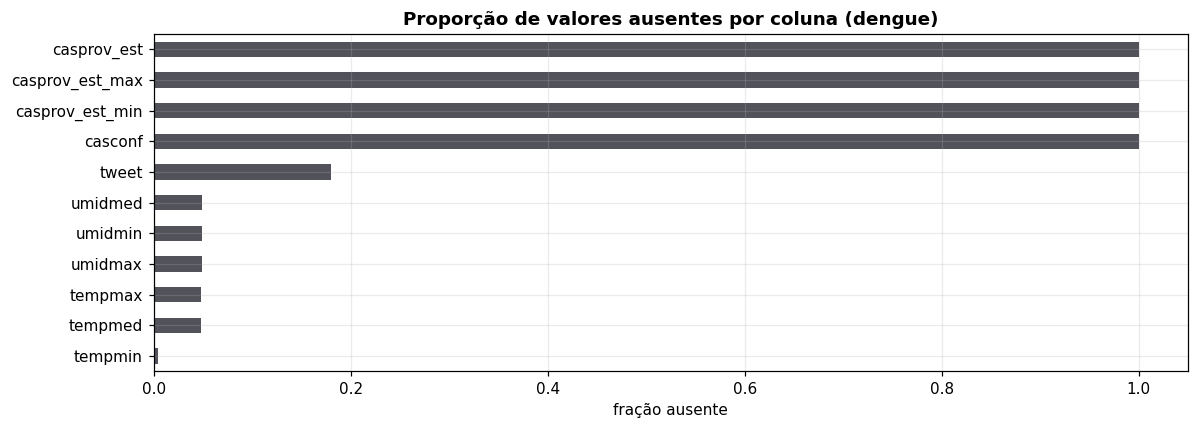

Obs.: casconf/casprov_est* vêm vazias; clima ausente nas semanas antigas e na mais recente.


In [4]:
# Valores ausentes por coluna
nul = df.isna().mean().sort_values(ascending=False)
nul = nul[nul > 0]
ax = nul.plot.barh(color=CINZA)
ax.invert_yaxis()
ax.set_title("Proporção de valores ausentes por coluna (dengue)")
ax.set_xlabel("fração ausente")
plt.tight_layout(); plt.show()
print("Obs.: casconf/casprov_est* vêm vazias; clima ausente nas semanas antigas e na mais recente.")

## 2. Série temporal de casos


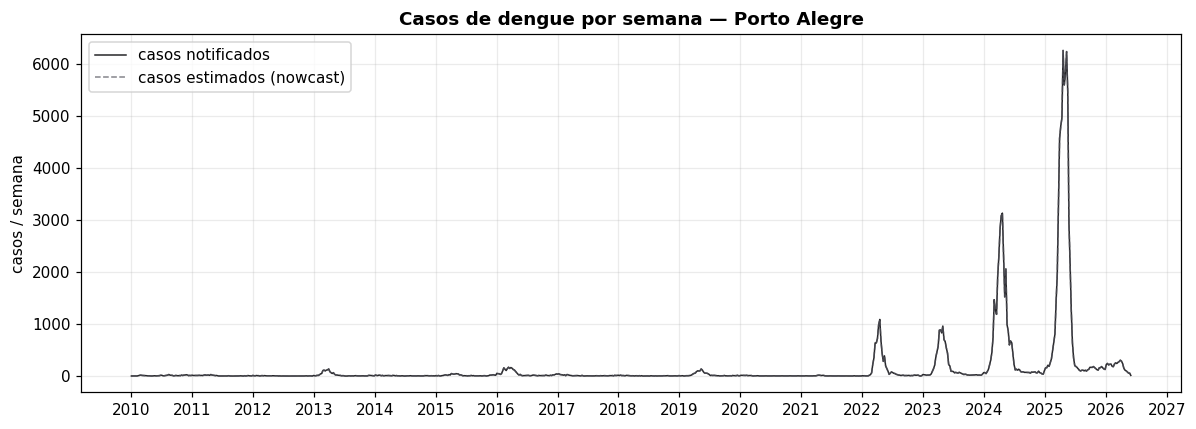

In [5]:
fig, ax = plt.subplots()
ax.plot(df["data"], df["casos"], lw=1, color=ESCURO, label="casos notificados")
ax.plot(df["data"], df["casos_est"], lw=1, ls="--", alpha=.7, color=CINZA, label="casos estimados (nowcast)")
ax.set_title("Casos de dengue por semana — Porto Alegre")
ax.set_ylabel("casos / semana"); ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

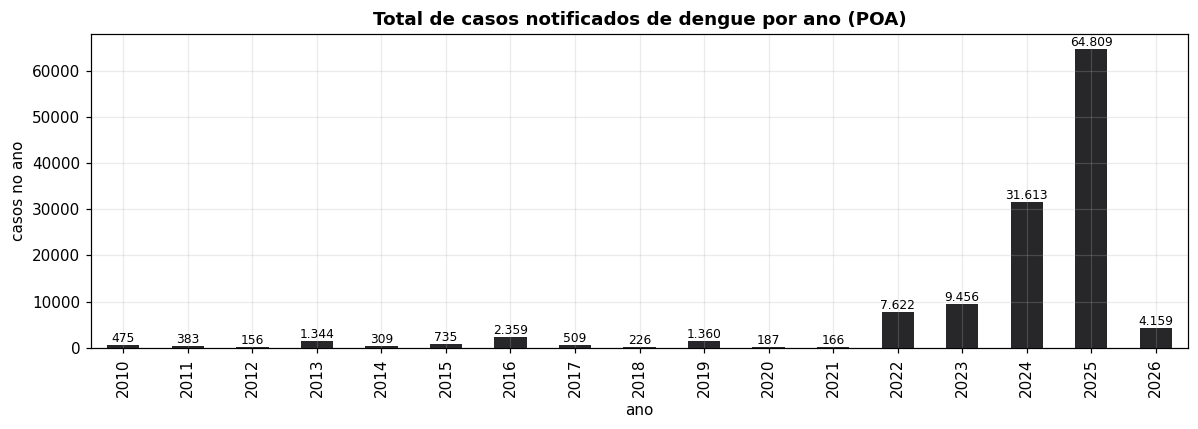

ano
2010      475
2011      383
2012      156
2013     1344
2014      309
2015      735
2016     2359
2017      509
2018      226
2019     1360
2020      187
2021      166
2022     7622
2023     9456
2024    31613
2025    64809
2026     4159
Name: casos, dtype: int64

In [6]:
por_ano = df.groupby("ano")["casos"].sum()
ax = por_ano.plot.bar(color=ESCURO)
ax.set_title("Total de casos notificados de dengue por ano (POA)")
ax.set_ylabel("casos no ano")
for i, v in enumerate(por_ano):
    ax.text(i, v, f"{int(v):,}".replace(",", "."), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
por_ano

## 3. Sazonalidade

Quando, dentro do ano, a dengue acontece em POA. Padrão esperado: pico no verão/outono (mar–mai).


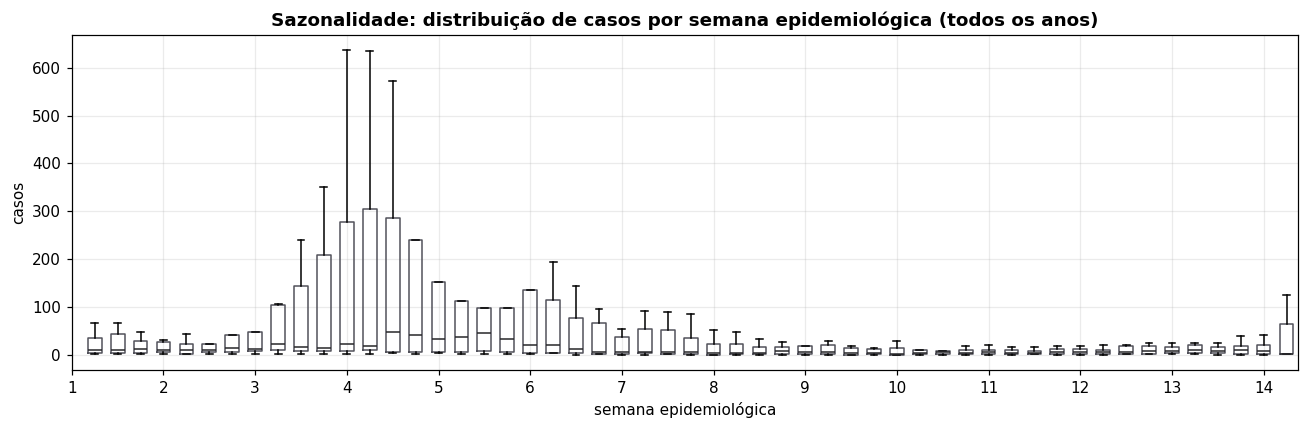

In [7]:
semanas = sorted(df["semana"].unique())
dados_box = [df.loc[df["semana"] == s, "casos"].values for s in semanas]
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(dados_box, positions=semanas, widths=.6, showfliers=False,
           medianprops=dict(color=ESCURO), boxprops=dict(color=CINZA))
ax.set_title("Sazonalidade: distribuição de casos por semana epidemiológica (todos os anos)")
ax.set_xlabel("semana epidemiológica"); ax.set_ylabel("casos")
ax.set_xticks(range(0, 54, 4))
plt.tight_layout(); plt.show()

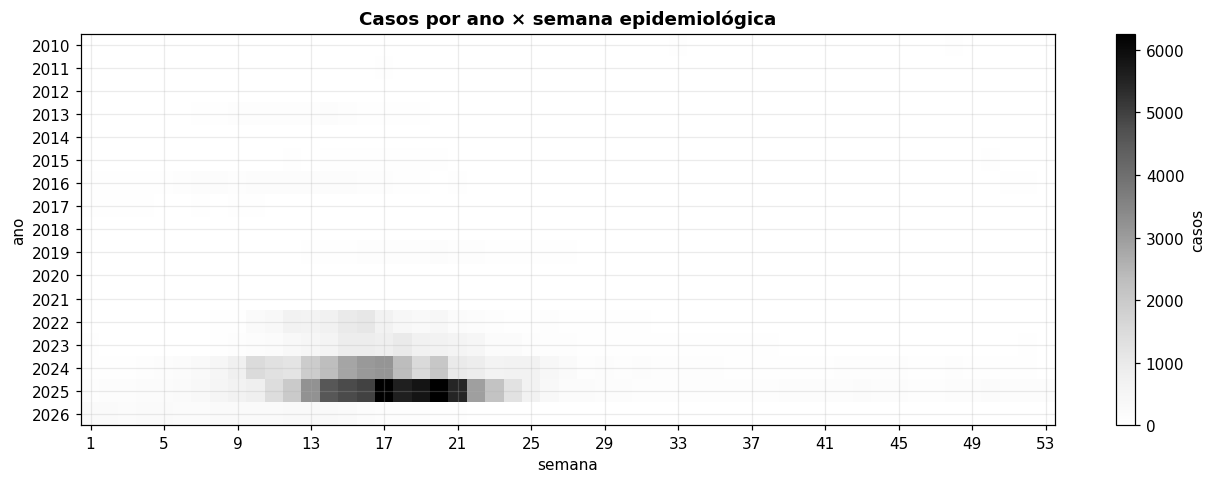

In [8]:
# Heatmap ano x semana (mais escuro = mais casos)
piv = df.pivot_table(index="ano", columns="semana", values="casos", aggfunc="sum")
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(piv.values, aspect="auto", cmap="Greys")
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xticks(range(0, len(piv.columns), 4)); ax.set_xticklabels(piv.columns[::4])
ax.set_title("Casos por ano × semana epidemiológica")
ax.set_xlabel("semana"); ax.set_ylabel("ano")
fig.colorbar(im, ax=ax, label="casos")
plt.tight_layout(); plt.show()

## 4. Nível de alerta e Rt


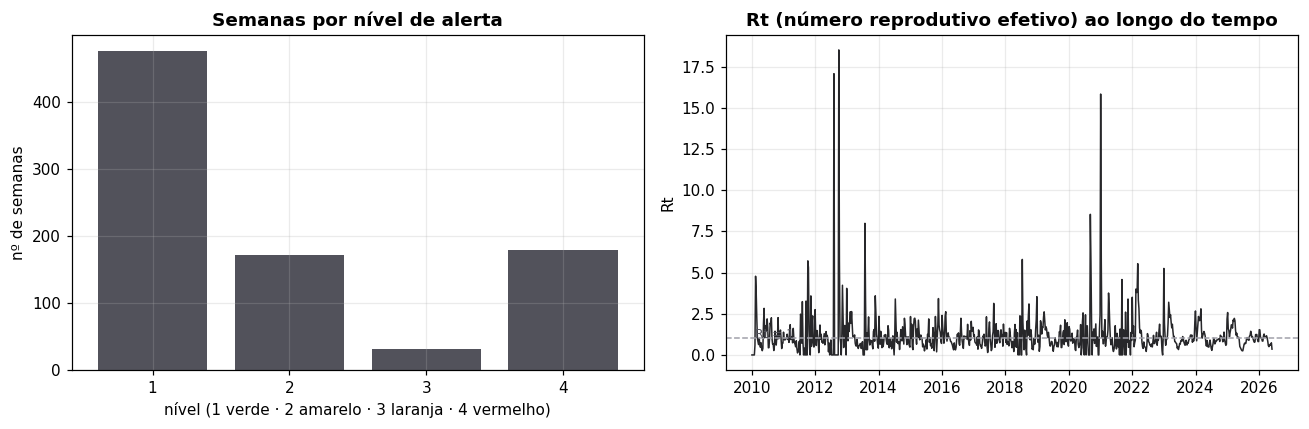

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cont = df["nivel"].value_counts().sort_index()
axes[0].bar(cont.index.astype(int).astype(str), cont.values, color=CINZA)
axes[0].set_title("Semanas por nível de alerta")
axes[0].set_xlabel("nível (1 verde · 2 amarelo · 3 laranja · 4 vermelho)")
axes[0].set_ylabel("nº de semanas")

axes[1].plot(df["data"], df["Rt"], lw=1, color=ESCURO)
axes[1].axhline(1, ls="--", lw=1, color=CINZA_CLARO)
axes[1].set_title("Rt (número reprodutivo efetivo) ao longo do tempo")
axes[1].set_ylabel("Rt")
axes[1].text(df["data"].iloc[5], 1.02, "Rt = 1", color=CINZA, fontsize=8)
plt.tight_layout(); plt.show()

## 5. Clima e relação com os casos

Temperatura e umidade modulam o ciclo do mosquito — interessa ver o efeito **defasado** (lags), que é o que um modelo usaria como feature.


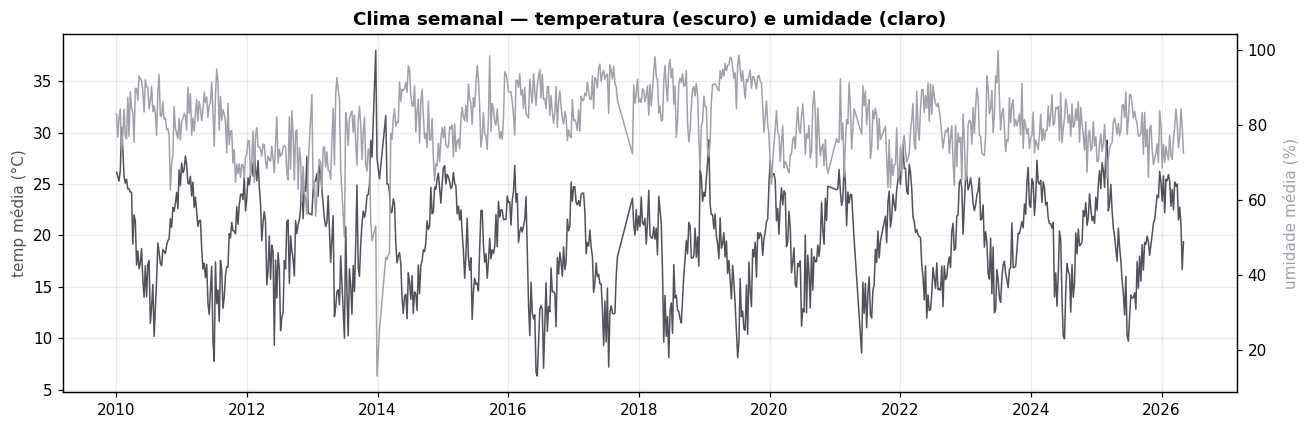

In [10]:
clima = df.dropna(subset=["tempmed", "umidmed"])
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(clima["data"], clima["tempmed"], color=CINZA, lw=1)
ax1.set_ylabel("temp média (°C)", color=CINZA)
ax2 = ax1.twinx()
ax2.plot(clima["data"], clima["umidmed"], color=CINZA_CLARO, lw=1)
ax2.set_ylabel("umidade média (%)", color=CINZA_CLARO)
ax2.grid(False)
ax1.set_title("Clima semanal — temperatura (escuro) e umidade (claro)")
plt.tight_layout(); plt.show()

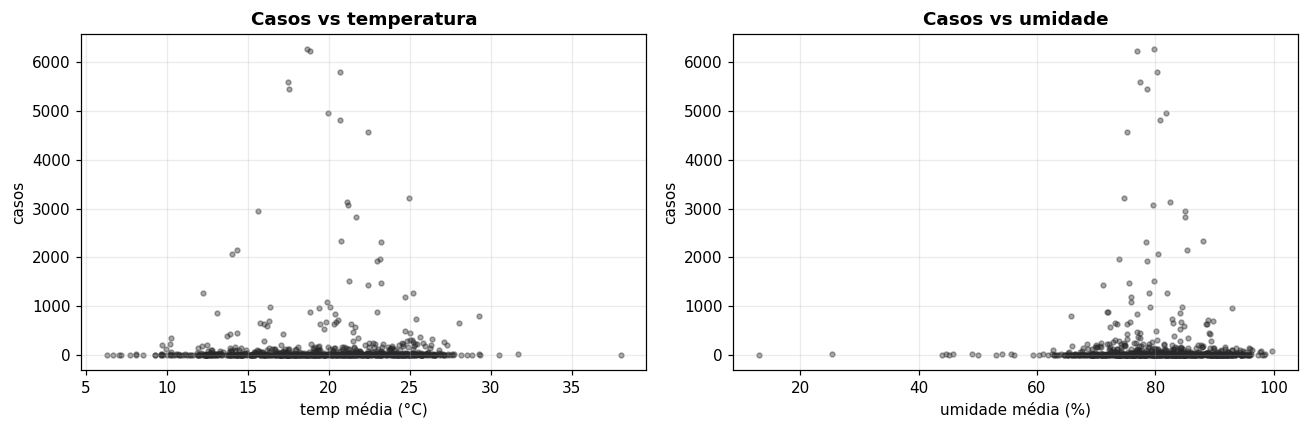

In [11]:
sub = df.dropna(subset=["tempmed", "umidmed"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sub["tempmed"], sub["casos"], s=10, alpha=.4, color=ESCURO)
axes[0].set_xlabel("temp média (°C)"); axes[0].set_ylabel("casos"); axes[0].set_title("Casos vs temperatura")
axes[1].scatter(sub["umidmed"], sub["casos"], s=10, alpha=.4, color=ESCURO)
axes[1].set_xlabel("umidade média (%)"); axes[1].set_ylabel("casos"); axes[1].set_title("Casos vs umidade")
plt.tight_layout(); plt.show()

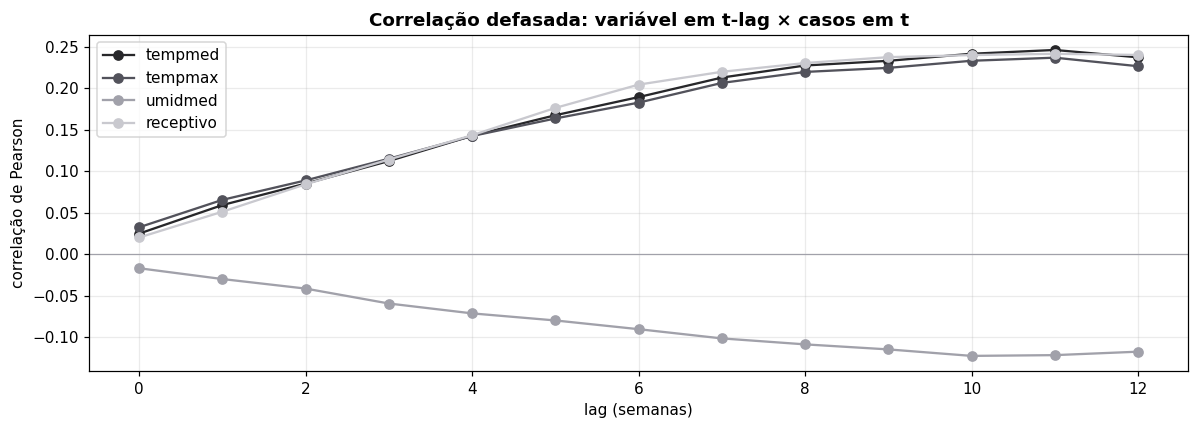

,tempmed,tempmax,umidmed,receptivo
0,0.03,0.03,-0.02,0.02
1,0.06,0.07,-0.03,0.05
2,0.09,0.09,-0.04,0.08
3,0.11,0.12,-0.06,0.11
4,0.14,0.14,-0.07,0.14
5,0.17,0.16,-0.08,0.18
6,0.19,0.18,-0.09,0.20
7,0.21,0.21,-0.10,0.22
8,0.23,0.22,-0.11,0.23
9,0.23,0.22,-0.11,0.24


In [12]:
# Correlação defasada: clima em (t - lag) vs casos em t
serie = df.set_index("data").sort_index()
casos = serie["casos"]
lags = list(range(0, 13))
corr_df = pd.DataFrame(
    {var: [serie[var].shift(l).corr(casos) for l in lags]
     for var in ["tempmed", "tempmax", "umidmed", "receptivo"]},
    index=lags,
)
ax = corr_df.plot(marker="o", color=[ESCURO, CINZA, CINZA_CLARO, "#c9c9cf"])
ax.set_title("Correlação defasada: variável em t-lag × casos em t")
ax.set_xlabel("lag (semanas)"); ax.set_ylabel("correlação de Pearson")
ax.axhline(0, color=CINZA_CLARO, lw=.8)
plt.tight_layout(); plt.show()
corr_df.round(2)

## 6. Dengue vs Zika vs Chikungunya


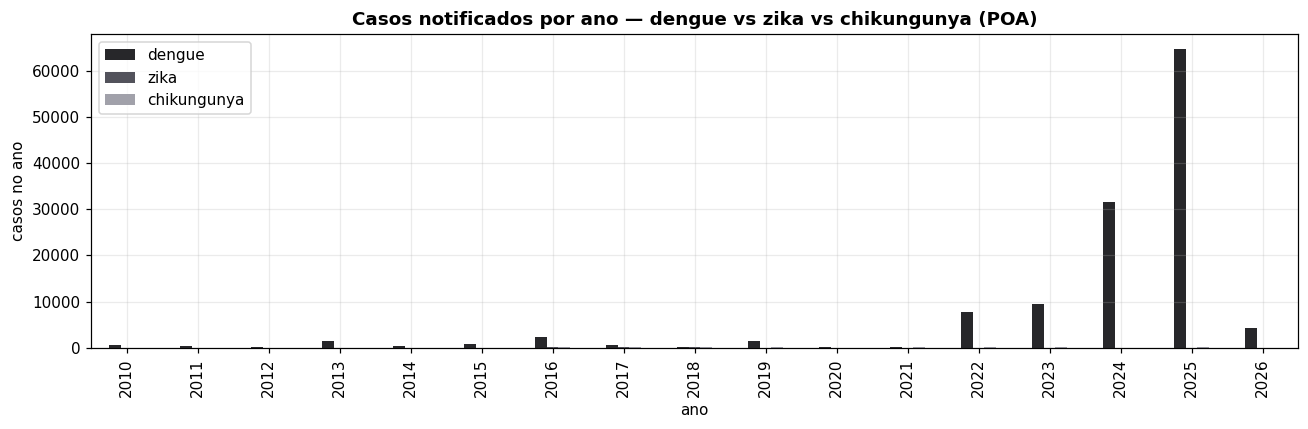

,dengue,zika,chikungunya
ano,,,
2010,475,0,0
2011,383,0,0
2012,156,0,0
2013,1344,0,0
2014,309,0,0
2015,735,1,12
2016,2359,218,150
2017,509,37,99
2018,226,72,89


In [13]:
comp = pd.DataFrame({d: dados[d].groupby("ano")["casos"].sum() for d in DOENCAS}).fillna(0).astype(int)
ax = comp.plot.bar(figsize=(12, 4), color=[ESCURO, CINZA, CINZA_CLARO])
ax.set_title("Casos notificados por ano — dengue vs zika vs chikungunya (POA)")
ax.set_ylabel("casos no ano")
plt.tight_layout(); plt.show()
comp

## Conclusões rápidas e próximos passos

**O que olhar nos gráficos acima:**
- Sazonalidade forte (pico verão/outono) → variável de sazonalidade é feature obrigatória.
- Crescimento brutal de 2022 em diante; 2024–2025 são os anos de epidemia.
- A correlação defasada clima→casos indica em quais *lags* (semanas) temperatura/umidade mais "antecipam" os casos — candidatos diretos a features.

**Próximos passos:**
- Cruzar esta série de casos+clima (semanal) com os dados **entomológicos** (Marília 2019–23 + raspagem 2025+) para montar a tabela de modelagem.
- Decidir a definição operacional de **surto** (percentil / canal endêmico) usando a série de incidência.
- Tratar o descasamento de "caso" (notificado InfoDengue vs confirmado SINAN).
